In [1]:
import sys
from pathlib import Path

Duong_Dan_Goc = Path(r"D:\HR Analytics")

sys.path.append(
    str(Duong_Dan_Goc / "python" / "src")
)

MODEL_DIR = Duong_Dan_Goc / "python" / "models"
OUTPUT_DIR = Duong_Dan_Goc / "python" / "outputs"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)   
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from db import get_engine

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    classification_report,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

from sklearn.base import clone

In [2]:
engine = get_engine()
query="""
select *
from dw.View_ML_NhanVien
order by NgayThang, MaNV
"""
df = pd.read_sql(query, engine)
df["NgayThang"] = pd.to_datetime(df["NgayThang"])
df.head()

,MaNV,NgayThang,Nam,PhongBan,ChucDanh,CapBacCongViec,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,LamThemGio,DiemDanhGiaHieuSuat,DiemHaiLongCongViec,DiemHaiLongMoiTruong,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,DuocThangChucNamTruoc,CoNghiViec
0,5,2018-01-01,2018,Information Technology,IT Support,2,41,15,5,194,False,3,2,3,16936000,7,7,False,0
1,6,2018-01-01,2018,Sales,Sales Supervisor,1,29,16,3,206,False,4,4,3,11779000,7,7,False,0
2,7,2018-01-01,2018,Operations,Operations Manager,2,28,36,1,177,False,2,2,3,15588000,4,4,False,1
3,8,2018-01-01,2018,Human Resources,C&B Specialist,3,35,3,4,240,True,3,1,4,33357000,6,6,False,0
4,10,2018-01-01,2018,Human Resources,C&B Specialist,2,38,35,3,166,False,4,2,2,15353000,4,4,False,0


In [3]:
# Tạo dataset chỉ lấy ngày 01/01
df_du_doan = df[
    (df["NgayThang"].dt.month == 1) &
    (df["NgayThang"].dt.day == 1)
].copy()

# Mục tiêu dự đoán là có nghỉ việc trong 12 tháng hay không
df_du_doan = df_du_doan.rename(
    columns={
        "CoNghiViec": "CoNghiViec12Thang"
    }
)
muc_tieu = "CoNghiViec12Thang"

In [4]:
train = df_du_doan[
    df_du_doan["Nam"].between(
        2018,
        2023
    )
].copy()

valid = df_du_doan[
    df_du_doan["Nam"] == 2024
].copy()

test = df_du_doan[
    df_du_doan["Nam"] == 2025
].copy()

In [5]:
featurea_So= [
    "Tuoi",
    "KhoangCachTuNha",
    "SoLuongDuAn",
    "SoGioTrungBinhThang",
    "DiemDanhGiaHieuSuat",
    "DiemHaiLongCongViec",
    "DiemHaiLongMoiTruong",
    "ThuNhapThang",
    "SoNamTaiCongTy",
    "SoNamTuLanThangChucCuoi",
    "CapBacCongViec"
]
features_Nhi_Phan = [
    "LamThemGio",
    "DuocThangChucNamTruoc"
]
features_danh_muc = [
    "PhongBan",
    "ChucDanh"
]
feature_cot =( featurea_So + features_Nhi_Phan + features_danh_muc)

In [6]:
X_train = train[
    feature_cot
].copy()

y_train = train[
    muc_tieu
].copy()

X_valid = valid[
    feature_cot
].copy()

y_valid = valid[
    muc_tieu
].copy()

X_test = test[
    feature_cot
].copy()

y_test = test[
    muc_tieu
].copy()

In [7]:
rf_tien_xu_ly = ColumnTransformer(
    transformers=[
        (
            "so",
            "passthrough",
            featurea_So
        ),

        (
            "nhi_phan",
            "passthrough",
            features_Nhi_Phan
        ),

        (
            "danh_muc",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            features_danh_muc
        )
    ]
)

In [8]:
ds_max_depth = [
    6,
    10,
    14,
    None
]

ds_min_samples_leaf = [
    5,
    10,
    20
]

ds_max_features = [
    "sqrt",
    0.7
]

ds_class_weight = [
    None,
    "balanced"
]

In [9]:
ket_qua_rf = []

for max_depth in ds_max_depth:

    for min_samples_leaf in (
        ds_min_samples_leaf
    ):

        for max_features in (
            ds_max_features
        ):

            for class_weight in (
                ds_class_weight
            ):

                rf_pipeline = Pipeline(
                    steps=[
                        (
                            "preprocessor",
                            rf_tien_xu_ly
                        ),

                        (
                            "model",
                            RandomForestClassifier(
                                n_estimators=300,
                                max_depth=max_depth,
                                min_samples_leaf=(
                                    min_samples_leaf
                                ),
                                max_features=(
                                    max_features
                                ),
                                class_weight=(
                                    class_weight
                                ),
                                random_state=42,
                                n_jobs=-1
                            )
                        )
                    ]
                )

                rf_pipeline.fit(
                    X_train,
                    y_train
                )

                xac_suat_valid_rf = (
                    rf_pipeline
                    .predict_proba(
                        X_valid
                    )[:, 1]
                )

                ket_qua_rf.append({
                    "NEstimators": 300,

                    "MaxDepth":
                        str(max_depth),

                    "MinSamplesLeaf":
                        min_samples_leaf,

                    "MaxFeatures":
                        str(max_features),

                    "ClassWeight":
                        str(class_weight),

                    "ROC_AUC":
                        roc_auc_score(
                            y_valid,
                            xac_suat_valid_rf
                        ),

                    "PR_AUC":
                        average_precision_score(
                            y_valid,
                            xac_suat_valid_rf
                        )
                })

In [10]:
ket_qua_rf = pd.DataFrame(
    ket_qua_rf
)

ket_qua_rf.sort_values(
    "PR_AUC",
    ascending=False
).head(15)

,NEstimators,MaxDepth,MinSamplesLeaf,MaxFeatures,ClassWeight,ROC_AUC,PR_AUC
20,300,10,20,sqrt,None,0.711438,0.327093
0,300,6,5,sqrt,None,0.710941,0.327000
32,300,14,20,sqrt,None,0.710748,0.326476
8,300,6,20,sqrt,None,0.710813,0.326165
5,300,6,10,sqrt,balanced,0.710402,0.326048
16,300,10,10,sqrt,None,0.711389,0.325995
1,300,6,5,sqrt,balanced,0.711100,0.325779
9,300,6,20,sqrt,balanced,0.711915,0.325502
44,300,None,20,sqrt,None,0.711547,0.325332
21,300,10,20,sqrt,balanced,0.710311,0.325273


In [11]:
best_row_rf = (
    ket_qua_rf
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .iloc[0]
)

BEST_DEPTH_RF = (
    None
    if best_row_rf[
        "MaxDepth"
    ] == "None"
    else int(
        best_row_rf[
            "MaxDepth"
        ]
    )
)

BEST_LEAF_RF = int(
    best_row_rf[
        "MinSamplesLeaf"
    ]
)

BEST_MAX_FEATURES_RF = (
    "sqrt"
    if best_row_rf[
        "MaxFeatures"
    ] == "sqrt"
    else float(
        best_row_rf[
            "MaxFeatures"
        ]
    )
)

BEST_CLASS_WEIGHT_RF = (
    None
    if best_row_rf[
        "ClassWeight"
    ] == "None"
    else "balanced"
)

print(
    "MaxDepth:",
    BEST_DEPTH_RF
)

print(
    "MinSamplesLeaf:",
    BEST_LEAF_RF
)

print(
    "MaxFeatures:",
    BEST_MAX_FEATURES_RF
)

print(
    "ClassWeight:",
    BEST_CLASS_WEIGHT_RF
)

print(
    "ROC-AUC:",
    best_row_rf[
        "ROC_AUC"
    ]
)

print(
    "PR-AUC:",
    best_row_rf[
        "PR_AUC"
    ]
)

MaxDepth: 10
MinSamplesLeaf: 20
MaxFeatures: sqrt
ClassWeight: None
ROC-AUC: 0.7114380396840737
PR-AUC: 0.32709265397147785


In [12]:
ds_n_estimators = [
    200,
    300,
    500,
    700
]

In [13]:
ket_qua_rf_tinh_chinh = []

for n_tree in ds_n_estimators:

    rf_model = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(
                    rf_tien_xu_ly
                )
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=n_tree,
                    max_depth=(
                        BEST_DEPTH_RF
                    ),
                    min_samples_leaf=(
                        BEST_LEAF_RF
                    ),
                    max_features=(
                        BEST_MAX_FEATURES_RF
                    ),
                    class_weight=(
                        BEST_CLASS_WEIGHT_RF
                    ),
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    rf_model.fit(
        X_train,
        y_train
    )

    xac_suat = (
        rf_model
        .predict_proba(
            X_valid
        )[:, 1]
    )

    ket_qua_rf_tinh_chinh.append({
        "NEstimators":
            n_tree,

        "ROC_AUC":
            roc_auc_score(
                y_valid,
                xac_suat
            ),

        "PR_AUC":
            average_precision_score(
                y_valid,
                xac_suat
            )
    })

ket_qua_rf_tinh_chinh = (
    pd.DataFrame(
        ket_qua_rf_tinh_chinh
    )
)

ket_qua_rf_tinh_chinh

,NEstimators,ROC_AUC,PR_AUC
0,200,0.710985,0.326187
1,300,0.711438,0.327093
2,500,0.711486,0.326143
3,700,0.711585,0.326357


In [14]:
best_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(rf_tien_xu_ly)
        ),

        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_leaf=20,
                max_features="sqrt",
                class_weight=None,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

best_rf.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Tuoi','KhoangCachTuNha','SoLuongDuAn',...,'DuocThangChucNamTruoc', 'PhongBan','ChucDanh']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('so', ...), ('nhi_phan', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [15]:
xac_suat_valid_rf = (
    best_rf
    .predict_proba(
        X_valid
    )[:, 1]
)

In [16]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        xac_suat_valid_rf
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_valid,
        xac_suat_valid_rf
    )
)

ROC-AUC: 0.7114380396840737
PR-AUC: 0.32709265397147785


In [17]:
ds_precision_rf, ds_recall_rf, ds_threshold_rf = (
    precision_recall_curve(
        y_valid,
        xac_suat_valid_rf
    )
)

f1_rf = (
    2
    * ds_precision_rf[:-1]
    * ds_recall_rf[:-1]
    /
    (
        ds_precision_rf[:-1]
        + ds_recall_rf[:-1]
        + 1e-9
    )
)

vi_tri_tot_nhat_rf = np.argmax(
    f1_rf
)

best_threshold_rf = (
    ds_threshold_rf[
        vi_tri_tot_nhat_rf
    ]
)

print(
    "Threshold:",
    round(best_threshold_rf, 4)
)

print(
    "Precision:",
    round(
        ds_precision_rf[
            vi_tri_tot_nhat_rf
        ],
        4
    )
)

print(
    "Recall:",
    round(
        ds_recall_rf[
            vi_tri_tot_nhat_rf
        ],
        4
    )
)

print(
    "F1:",
    round(
        f1_rf[
            vi_tri_tot_nhat_rf
        ],
        4
    )
)

Threshold: 0.1691
Precision: 0.2794
Recall: 0.6325
F1: 0.3876


In [18]:
bang_threshold_rf = pd.DataFrame({
    "Threshold":
        ds_threshold_rf,

    "Precision":
        ds_precision_rf[:-1],

    "Recall":
        ds_recall_rf[:-1],

    "F1":
        f1_rf
})

bang_threshold_rf = (
    bang_threshold_rf
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

bang_threshold_rf.head(15)

,Threshold,Precision,Recall,F1
0,0.169088,0.279432,0.632466,0.387611
1,0.169067,0.279243,0.632466,0.387430
2,0.169047,0.279054,0.632466,0.387248
3,0.168952,0.278866,0.632466,0.387067
4,0.169216,0.279133,0.630934,0.387036
5,0.182750,0.291829,0.574273,0.386997
6,0.169925,0.279673,0.627871,0.386975
7,0.168706,0.278413,0.633997,0.386916
8,0.168915,0.278677,0.632466,0.386885
9,0.169216,0.278944,0.630934,0.386854


In [19]:
# Ngưỡng cao 
nguong_cao = float(best_threshold_rf)

# Lấy ra danh sách các xác suất nằm dưới ngưỡng cao
xac_suat_duoi_nguong = xac_suat_valid_rf[xac_suat_valid_rf < nguong_cao]

# Ngưỡng trung bình là điểm chia đôi (median) của nhóm xác suất dưới ngưỡng cao
nguong_trung_binh = float(np.median(xac_suat_duoi_nguong))

print("Ngưỡng Trung bình:", round(nguong_trung_binh, 6))
print("Ngưỡng Cao:", round(nguong_cao, 6))

Ngưỡng Trung bình: 0.100162
Ngưỡng Cao: 0.169088


In [20]:
def phan_loai_rui_ro(
    xac_suat
):

    if xac_suat >= nguong_cao:
        return "Cao"

    elif xac_suat >= nguong_trung_binh:
        return "Trung bình"

    else:
        return "Thấp"

In [21]:
kiem_tra_rui_ro_valid = valid[
    [
        "MaNV",
        "PhongBan",
        "ChucDanh"
    ]
].copy()

thu_tu_rui_ro = [
    "Thấp",
    "Trung bình",
    "Cao"
]

kiem_tra_rui_ro_valid[
    "ThucTeNghiViec"
] = y_valid.values

kiem_tra_rui_ro_valid[
    "XacSuatNghiViec"
] = xac_suat_valid_rf

kiem_tra_rui_ro_valid[
    "MucRuiRo"
] = (
    kiem_tra_rui_ro_valid[
        "XacSuatNghiViec"
    ]
    .apply(
        phan_loai_rui_ro
    )
)

danh_gia_muc_rui_ro_valid = (
    kiem_tra_rui_ro_valid
    .groupby(
        "MucRuiRo"
    )
    .agg(
        SoNhanVien=(
            "MaNV",
            "count"
        ),

        SoNghiViec=(
            "ThucTeNghiViec",
            "sum"
        ),

        DiemNguyCoTB=(
            "XacSuatNghiViec",
            "mean"
        )
    )
    .reindex(
        thu_tu_rui_ro
    )
)

danh_gia_muc_rui_ro_valid[
    "TyLeNghiViecThucTe"
] = (
    danh_gia_muc_rui_ro_valid[
        "SoNghiViec"
    ]
    /
    danh_gia_muc_rui_ro_valid[
        "SoNhanVien"
    ]
    * 100
)

danh_gia_muc_rui_ro_valid.round(4)

,SoNhanVien,SoNghiViec,DiemNguyCoTB,TyLeNghiViecThucTe
MucRuiRo,,,,
Thấp,1441,87,0.0768,6.0375
Trung bình,1442,153,0.1307,10.6103
Cao,1478,413,0.2515,27.9432


In [22]:
nhan_du_doan_valid_rf = (
    xac_suat_valid_rf
    >= best_threshold_rf
).astype(int)

In [23]:
ket_qua_valid_rf = pd.DataFrame({
    "ChiSo": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],

    "GiaTri": [
        accuracy_score(
            y_valid,
            nhan_du_doan_valid_rf
        ),

        precision_score(
            y_valid,
            nhan_du_doan_valid_rf
        ),

        recall_score(
            y_valid,
            nhan_du_doan_valid_rf
        ),

        f1_score(
            y_valid,
            nhan_du_doan_valid_rf
        ),

        roc_auc_score(
            y_valid,
            xac_suat_valid_rf
        ),

        average_precision_score(
            y_valid,
            xac_suat_valid_rf
        )
    ]
})

ket_qua_valid_rf.round(4)

,ChiSo,GiaTri
0,Accuracy,0.7008
1,Precision,0.2794
2,Recall,0.6325
3,F1,0.3876
4,ROC_AUC,0.7114
5,PR_AUC,0.3271


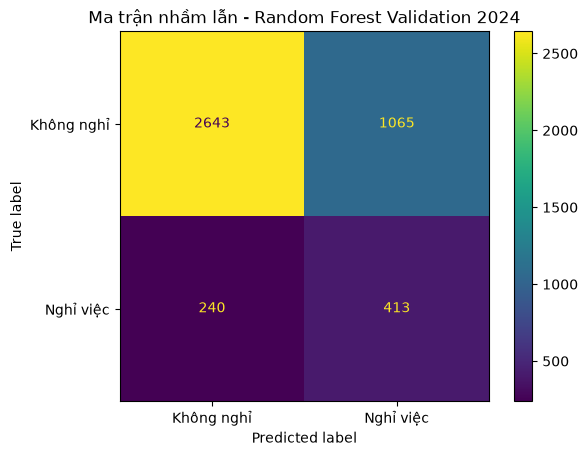

In [24]:
ma_tran_valid_rf = confusion_matrix(
    y_valid,
    nhan_du_doan_valid_rf
)

hien_thi_rf = ConfusionMatrixDisplay(
    confusion_matrix=ma_tran_valid_rf,
    display_labels=[
        "Không nghỉ",
        "Nghỉ việc"
    ]
)

hien_thi_rf.plot()

plt.title(
    "Ma trận nhầm lẫn - Random Forest Validation 2024"
)

plt.show()

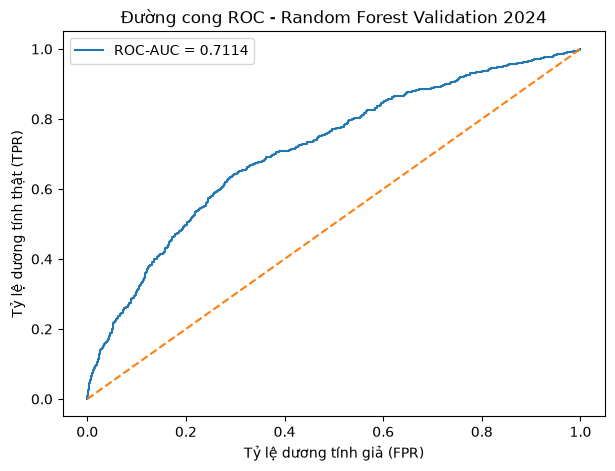

In [25]:
fpr_rf, tpr_rf, _ = roc_curve(
    y_valid,
    xac_suat_valid_rf
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=(
        f"ROC-AUC = "
        f"{roc_auc_score(y_valid, xac_suat_valid_rf):.4f}"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "Tỷ lệ dương tính giả (FPR)"
)

plt.ylabel(
    "Tỷ lệ dương tính thật (TPR)"
)

plt.title(
    "Đường cong ROC - Random Forest Validation 2024"
)

plt.legend()

plt.show()

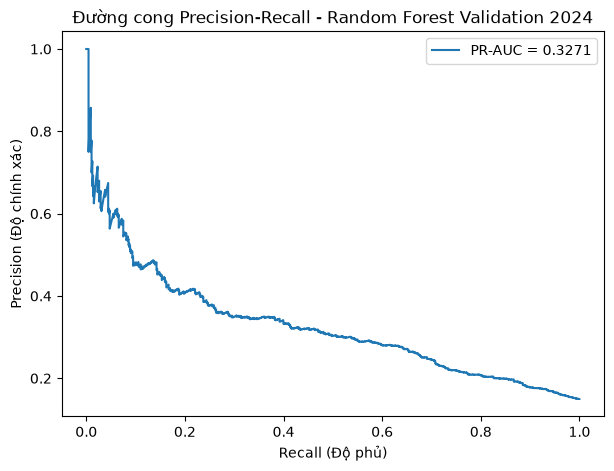

In [26]:
precision_curve_rf, recall_curve_rf, _ = (
    precision_recall_curve(
        y_valid,
        xac_suat_valid_rf
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve_rf,
    precision_curve_rf,
    label=(
        f"PR-AUC = "
        f"{average_precision_score(y_valid, xac_suat_valid_rf):.4f}"
    )
)

plt.xlabel(
    "Recall (Độ phủ)"
)

plt.ylabel(
    "Precision (Độ chính xác)"
)

plt.title(
    "Đường cong Precision-Recall - Random Forest Validation 2024"
)

plt.legend()

plt.show()

In [27]:
bo_tien_xu_ly_rf = (
    best_rf
    .named_steps[
        "preprocessor"
    ]
)

ten_feature_rf = (
    bo_tien_xu_ly_rf
    .get_feature_names_out()
)

mo_hinh_rf = (
    best_rf
    .named_steps[
        "model"
    ]
)

do_quan_trong_rf = pd.DataFrame({
    "Feature":
        ten_feature_rf,

    "Importance":
        mo_hinh_rf.feature_importances_
})

In [28]:
do_quan_trong_rf["Feature"] = (
    do_quan_trong_rf["Feature"]
    .str.replace(
        "so__",
        "",
        regex=False
    )
    .str.replace(
        "nhi_phan__",
        "",
        regex=False
    )
    .str.replace(
        "danh_muc__",
        "",
        regex=False
    )
)

In [29]:
do_quan_trong_rf = (
    do_quan_trong_rf
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

do_quan_trong_rf.head(15)

,Feature,Importance
0,LamThemGio,0.248812
1,SoGioTrungBinhThang,0.223758
2,DiemHaiLongCongViec,0.128432
3,DiemHaiLongMoiTruong,0.064993
4,ThuNhapThang,0.053551
5,SoLuongDuAn,0.046873
6,KhoangCachTuNha,0.041113
7,SoNamTuLanThangChucCuoi,0.039492
8,Tuoi,0.037184
9,SoNamTaiCongTy,0.031332


In [30]:
final_train_rf = df_du_doan[
    df_du_doan["Nam"].between(
        2018,
        2024
    )
].copy()

final_test_rf = df_du_doan[
    df_du_doan["Nam"] == 2025
].copy()

print("Final Train:")
print(
    final_train_rf[
        "Nam"
    ].value_counts().sort_index()
)

print("\nFinal Test:")
print(
    final_test_rf[
        "Nam"
    ].value_counts().sort_index()
)

Final Train:
Nam
2018    4312
2019    4125
2020    4053
2021    4178
2022    4188
2023    4318
2024    4361
Name: count, dtype: int64

Final Test:
Nam
2025    4431
Name: count, dtype: int64


In [31]:
X_final_train_rf = (
    final_train_rf[
        feature_cot
    ].copy()
)

y_final_train_rf = (
    final_train_rf[
        muc_tieu
    ].copy()
)

X_final_test_rf = (
    final_test_rf[
        feature_cot
    ].copy()
)

y_final_test_rf = (
    final_test_rf[
        muc_tieu
    ].copy()
)

print(
    "Final Train:",
    X_final_train_rf.shape
)

print(
    "Final Test:",
    X_final_test_rf.shape
)

Final Train: (29535, 15)
Final Test: (4431, 15)


In [32]:
final_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                rf_tien_xu_ly
            )
        ),

        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_leaf=20,
                max_features="sqrt",
                class_weight=None,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

final_rf.fit(
    X_final_train_rf,
    y_final_train_rf
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Tuoi','KhoangCachTuNha','SoLuongDuAn',...,'DuocThangChucNamTruoc', 'PhongBan','ChucDanh']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('so', ...), ('nhi_phan', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [33]:
xac_suat_test_rf = (
    final_rf
    .predict_proba(
        X_final_test_rf
    )[:, 1]
)

nhan_du_doan_test_rf = (
    xac_suat_test_rf
    >= best_threshold_rf
).astype(int)

In [34]:
ket_qua_test_rf = pd.DataFrame({
    "ChiSo": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],

    "GiaTri": [
        accuracy_score(
            y_final_test_rf,
            nhan_du_doan_test_rf
        ),

        precision_score(
            y_final_test_rf,
            nhan_du_doan_test_rf
        ),

        recall_score(
            y_final_test_rf,
            nhan_du_doan_test_rf
        ),

        f1_score(
            y_final_test_rf,
            nhan_du_doan_test_rf
        ),

        roc_auc_score(
            y_final_test_rf,
            xac_suat_test_rf
        ),

        average_precision_score(
            y_final_test_rf,
            xac_suat_test_rf
        )
    ]
})

ket_qua_test_rf.round(4)

,ChiSo,GiaTri
0,Accuracy,0.6944
1,Precision,0.2685
2,Recall,0.6024
3,F1,0.3714
4,ROC_AUC,0.7197
5,PR_AUC,0.3330


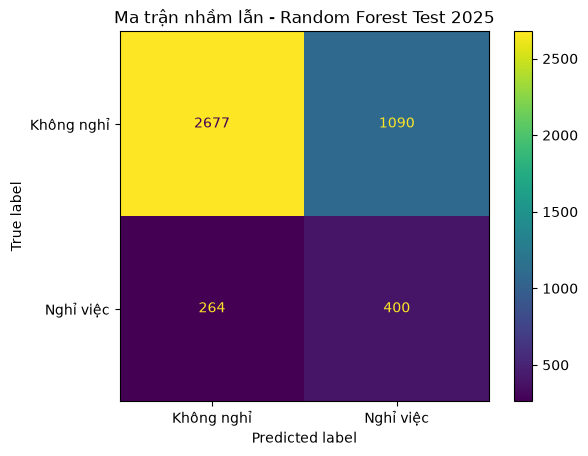

In [35]:
ma_tran_test_rf = confusion_matrix(
    y_final_test_rf,
    nhan_du_doan_test_rf
)

hien_thi_rf_test = (
    ConfusionMatrixDisplay(
        confusion_matrix=(
            ma_tran_test_rf
        ),
        display_labels=[
            "Không nghỉ",
            "Nghỉ việc"
        ]
    )
)

hien_thi_rf_test.plot()

plt.title(
    "Ma trận nhầm lẫn - "
    "Random Forest Test 2025"
)
plt.savefig(
    OUTPUT_DIR
    / "rf_ma_tran_nham_lan_2025.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [36]:
print(
    classification_report(
        y_final_test_rf,
        nhan_du_doan_test_rf,
        target_names=[
            "Không nghỉ",
            "Nghỉ việc"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

  Không nghỉ     0.9102    0.7106    0.7982      3767
   Nghỉ việc     0.2685    0.6024    0.3714       664

    accuracy                         0.6944      4431
   macro avg     0.5893    0.6565    0.5848      4431
weighted avg     0.8141    0.6944    0.7342      4431



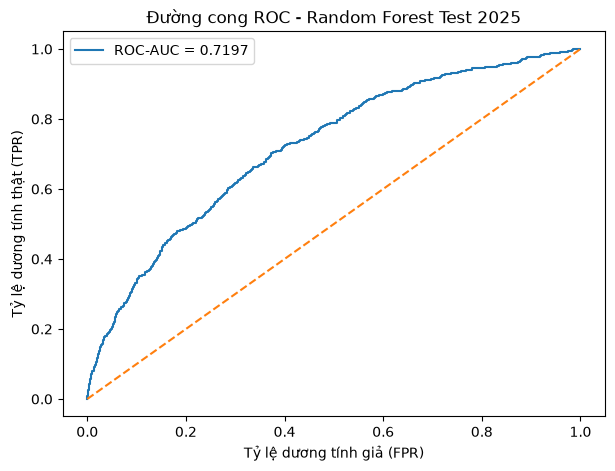

In [37]:
fpr_rf_test, tpr_rf_test, _ = roc_curve(
    y_final_test_rf,
    xac_suat_test_rf
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_rf_test,
    tpr_rf_test,
    label=(
        f"ROC-AUC = "
        f"{roc_auc_score(y_final_test_rf, xac_suat_test_rf):.4f}"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "Tỷ lệ dương tính giả (FPR)"
)

plt.ylabel(
    "Tỷ lệ dương tính thật (TPR)"
)

plt.title(
    "Đường cong ROC - Random Forest Test 2025"
)

plt.legend()
plt.savefig(
    OUTPUT_DIR / "rf_roc_2025.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

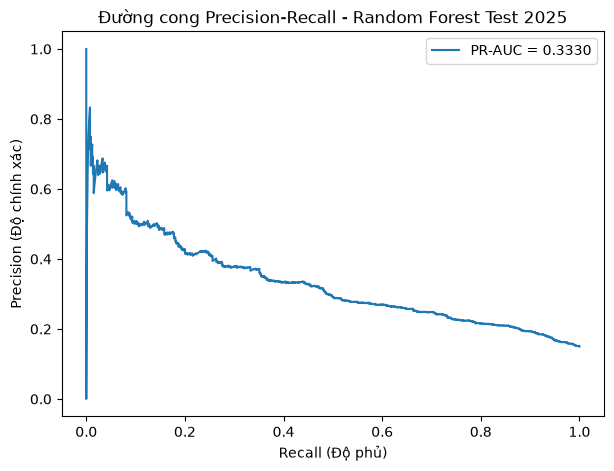

In [38]:
precision_rf_test, recall_rf_test, _ = (
    precision_recall_curve(
        y_final_test_rf,
        xac_suat_test_rf
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_rf_test,
    precision_rf_test,
    label=(
        f"PR-AUC = "
        f"{average_precision_score(y_final_test_rf, xac_suat_test_rf):.4f}"
    )
)

plt.xlabel(
    "Recall (Độ phủ)"
)

plt.ylabel(
    "Precision (Độ chính xác)"
)

plt.title(
    "Đường cong Precision-Recall - Random Forest Test 2025"
)

plt.legend()
plt.savefig(
    OUTPUT_DIR
    / "rf_precision_recall_2025.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [39]:
ket_qua_du_doan_rf = (
    final_test_rf[
        [
            "MaNV",
            "NgayThang",
            "Nam",
            "PhongBan",
            "ChucDanh"
        ]
    ]
    .copy()
)

ket_qua_du_doan_rf[
    "ThucTeNghiViec"
] = y_final_test_rf.values

ket_qua_du_doan_rf[
    "XacSuatNghiViec"
] = xac_suat_test_rf

ket_qua_du_doan_rf[
    "DuDoanNghiViec"
] = nhan_du_doan_test_rf

ket_qua_du_doan_rf[
    "NguongDuDoan"
] = best_threshold_rf

ket_qua_du_doan_rf.head(10)

,MaNV,NgayThang,Nam,PhongBan,ChucDanh,ThucTeNghiViec,XacSuatNghiViec,DuDoanNghiViec,NguongDuDoan
35210,1,2025-01-01,2025,Sales,Sales Representative,0,0.161676,0,0.169088
35211,3,2025-01-01,2025,Finance,Finance Manager,0,0.234315,1,0.169088
35212,4,2025-01-01,2025,Human Resources,Recruiter,0,0.127860,0,0.169088
35213,5,2025-01-01,2025,Information Technology,IT Support,0,0.130055,0,0.169088
35214,10,2025-01-01,2025,Human Resources,C&B Specialist,1,0.145572,0,0.169088
35215,13,2025-01-01,2025,Sales,Sales Executive,1,0.308302,1,0.169088
35216,21,2025-01-01,2025,Human Resources,Recruiter,0,0.305350,1,0.169088
35217,24,2025-01-01,2025,Sales,Sales Representative,1,0.189645,1,0.169088
35218,28,2025-01-01,2025,Human Resources,C&B Specialist,1,0.117052,0,0.169088
35219,29,2025-01-01,2025,Human Resources,Recruiter,1,0.134948,0,0.169088


In [40]:
ket_qua_du_doan_rf[
    "MucRuiRo"
] = (
    ket_qua_du_doan_rf[
        "XacSuatNghiViec"
    ]
    .apply(
        phan_loai_rui_ro
    )
)

ket_qua_du_doan_rf[
    "ThuTuRuiRo"
] = (
    ket_qua_du_doan_rf[
        "MucRuiRo"
    ]
    .map({
        "Thấp": 1,
        "Trung bình": 2,
        "Cao": 3
    })
)

In [41]:
ket_qua_du_doan_rf[
    "DiemNguyCo"
] = (
    ket_qua_du_doan_rf[
        "XacSuatNghiViec"
    ]
    * 100
).round(2)

ket_qua_du_doan_rf[
    "LaRuiRoCao"
] = (
    ket_qua_du_doan_rf[
        "MucRuiRo"
    ] == "Cao"
).astype(int)

ket_qua_du_doan_rf[
    "LaRuiRoTrungBinh"
] = (
    ket_qua_du_doan_rf[
        "MucRuiRo"
    ] == "Trung bình"
).astype(int)

ket_qua_du_doan_rf[
    "LaRuiRoThap"
] = (
    ket_qua_du_doan_rf[
        "MucRuiRo"
    ] == "Thấp"
).astype(int)

ket_qua_du_doan_rf[
    "XepHangNguyCo"
] = (
    ket_qua_du_doan_rf[
        "XacSuatNghiViec"
    ]
    .rank(
        method="first",
        ascending=False
    )
    .astype(int)
)

ket_qua_du_doan_rf[
    "PhanViNguyCo"
] = (
    ket_qua_du_doan_rf[
        "XacSuatNghiViec"
    ]
    .rank(
        pct=True
    )
    * 100
).round(2)

In [42]:
cot_powerbi = [
    "MaNV",
    "NgayThang",
    "Nam",

    "PhongBan",
    "ChucDanh",
    "CapBacCongViec",

    "Tuoi",
    "KhoangCachTuNha",

    "SoLuongDuAn",
    "SoGioTrungBinhThang",
    "LamThemGio",

    "DiemDanhGiaHieuSuat",
    "DiemHaiLongCongViec",
    "DiemHaiLongMoiTruong",

    "ThuNhapThang",

    "SoNamTaiCongTy",
    "SoNamTuLanThangChucCuoi",
    "DuocThangChucNamTruoc"
]

ket_qua_powerbi_rf = (
    final_test_rf[
        cot_powerbi
    ]
    .copy()
)

In [43]:
ket_qua_powerbi_rf[
    "ThucTeNghiViec"
] = y_final_test_rf.values

ket_qua_powerbi_rf[
    "XacSuatNghiViec"
] = xac_suat_test_rf

ket_qua_powerbi_rf[
    "DiemNguyCo"
] = (
    xac_suat_test_rf
    * 100
).round(2)

ket_qua_powerbi_rf[
    "DuDoanNghiViec"
] = nhan_du_doan_test_rf

ket_qua_powerbi_rf[
    "NguongDuDoan"
] = best_threshold_rf

In [44]:
ket_qua_powerbi_rf[
    "MucRuiRo"
] = (
    ket_qua_powerbi_rf[
        "XacSuatNghiViec"
    ]
    .apply(
        phan_loai_rui_ro
    )
)

ket_qua_powerbi_rf[
    "ThuTuRuiRo"
] = (
    ket_qua_powerbi_rf[
        "MucRuiRo"
    ]
    .map({
        "Thấp": 1,
        "Trung bình": 2,
        "Cao": 3
    })
)

In [45]:
ket_qua_powerbi_rf[
    "LaRuiRoCao"
] = (
    ket_qua_powerbi_rf[
        "MucRuiRo"
    ] == "Cao"
).astype(int)

In [46]:
ket_qua_powerbi_rf[
    "XepHangNguyCo"
] = (
    ket_qua_powerbi_rf[
        "XacSuatNghiViec"
    ]
    .rank(
        method="first",
        ascending=False
    )
    .astype(int)
)

ket_qua_powerbi_rf[
    "PhanViNguyCo"
] = (
    ket_qua_powerbi_rf[
        "XacSuatNghiViec"
    ]
    .rank(
        pct=True
    )
    * 100
).round(2)

In [47]:
ket_qua_powerbi_rf[
    "MoHinh"
] = "Random Forest"

ket_qua_powerbi_rf[
    "PhienBanMoHinh"
] = "RF_2025_V1"

In [48]:
print(
    "Tổng nhân viên:",
    len(
        ket_qua_powerbi_rf
    )
)

print(
    "\nPhân bố mức rủi ro:"
)

print(
    ket_qua_powerbi_rf[
        "MucRuiRo"
    ]
    .value_counts()
)

print(
    "\nTổng DuDoanNghiViec:"
)

print(
    ket_qua_powerbi_rf[
        "DuDoanNghiViec"
    ]
    .value_counts()
)

Tổng nhân viên: 4431

Phân bố mức rủi ro:
MucRuiRo
Trung bình    1504
Cao           1490
Thấp          1437
Name: count, dtype: int64

Tổng DuDoanNghiViec:
DuDoanNghiViec
0    2941
1    1490
Name: count, dtype: int64


In [49]:
tong_hop_rui_ro_2025 = (
    ket_qua_powerbi_rf
    .groupby(
        "MucRuiRo"
    )
    .agg(
        SoNhanVien=(
            "MaNV",
            "count"
        ),

        SoNghiViecThucTe=(
            "ThucTeNghiViec",
            "sum"
        ),

        DiemNguyCoTB=(
            "DiemNguyCo",
            "mean"
        )
    )
    .reindex(
        [
            "Thấp",
            "Trung bình",
            "Cao"
        ]
    )
)

tong_hop_rui_ro_2025[
    "TyLeNghiViecThucTe"
] = (
    tong_hop_rui_ro_2025[
        "SoNghiViecThucTe"
    ]
    /
    tong_hop_rui_ro_2025[
        "SoNhanVien"
    ]
    * 100
)

tong_hop_rui_ro_2025.round(2)

,SoNhanVien,SoNghiViecThucTe,DiemNguyCoTB,TyLeNghiViecThucTe
MucRuiRo,,,,
Thấp,1437,77,7.73,5.36
Trung bình,1504,187,13.08,12.43
Cao,1490,400,25.38,26.85


In [50]:
import joblib

joblib.dump(
    final_rf,
    MODEL_DIR / "random_forest_model.pkl"
)


['D:\\HR Analytics\\python\\models\\random_forest_model.pkl']

In [51]:
import json

cau_hinh_rf = {
    "MoHinh": "RandomForestClassifier",

    "NamTrain": "2018-2024",
    "NamValidation": 2024,
    "NamTest": 2025,

    "NEstimators": 300,
    "MaxDepth": 10,
    "MinSamplesLeaf": 20,
    "MaxFeatures": "sqrt",
    "ClassWeight": None,
    "RandomState": 42,

    "NguongDuDoan": float(
        best_threshold_rf
    ),

    "MucTieu": muc_tieu,

    "FeatureSo": featurea_So,
    "FeatureNhiPhan": features_Nhi_Phan,
    "FeatureDanhMuc": features_danh_muc,
    "TatCaFeature": feature_cot,

    "TestMetrics": {
        "Accuracy": float(
            accuracy_score(
                y_final_test_rf,
                nhan_du_doan_test_rf
            )
        ),

        "Precision": float(
            precision_score(
                y_final_test_rf,
                nhan_du_doan_test_rf
            )
        ),

        "Recall": float(
            recall_score(
                y_final_test_rf,
                nhan_du_doan_test_rf
            )
        ),

        "F1": float(
            f1_score(
                y_final_test_rf,
                nhan_du_doan_test_rf
            )
        ),

        "ROC_AUC": float(
            roc_auc_score(
                y_final_test_rf,
                xac_suat_test_rf
            )
        ),

        "PR_AUC": float(
            average_precision_score(
                y_final_test_rf,
                xac_suat_test_rf
            )
        )
    }
}

with open(
    MODEL_DIR / "random_forest_config.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        cau_hinh_rf,
        f,
        ensure_ascii=False,
        indent=4
    )

In [52]:
ket_qua_rf.to_csv(
    OUTPUT_DIR / "random_forest_tuning.csv",
    index=False,
    encoding="utf-8-sig"
)

ket_qua_rf_tinh_chinh.to_csv(
    OUTPUT_DIR / "random_forest_tuning_n_estimators.csv",
    index=False,
    encoding="utf-8-sig"
)

bang_threshold_rf.to_csv(
    OUTPUT_DIR / "random_forest_threshold.csv",
    index=False,
    encoding="utf-8-sig"
)

ket_qua_valid_rf.to_csv(
    OUTPUT_DIR / "random_forest_validation_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

ket_qua_test_rf.to_csv(
    OUTPUT_DIR / "random_forest_test_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

ket_qua_du_doan_rf.to_csv(
    OUTPUT_DIR / "random_forest_du_doan_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

do_quan_trong_rf.to_csv(
    OUTPUT_DIR / "random_forest_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

In [53]:
so_sanh_3_mo_hinh = pd.DataFrame({
    "MoHinh": [
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        0.7064,
        0.7504,
        0.6944
    ],

    "Precision": [
        0.2707,
        0.2980,
        0.2685
    ],

    "Recall": [
        0.5663,
        0.4910,
        0.6024
    ],

    "F1": [
        0.3663,
        0.3709,
        0.3714
    ],

    "ROC_AUC": [
        0.6907,
        0.7112,
        0.7197
    ],

    "PR_AUC": [
        0.3002,
        0.2994,
        0.3330
    ]
})

so_sanh_3_mo_hinh.to_csv(
    OUTPUT_DIR / "so_sanh_3_mo_hinh.csv",
    index=False,
    encoding="utf-8-sig"
)

so_sanh_3_mo_hinh

,MoHinh,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,KNN,0.7064,0.2707,0.5663,0.3663,0.6907,0.3002
1,Decision Tree,0.7504,0.2980,0.4910,0.3709,0.7112,0.2994
2,Random Forest,0.6944,0.2685,0.6024,0.3714,0.7197,0.3330


In [54]:
ket_qua_powerbi_rf.to_csv(
    OUTPUT_DIR
    / "random_forest_powerbi_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

tong_hop_rui_ro_2025.to_csv(
    OUTPUT_DIR
    / "random_forest_tong_hop_rui_ro_2025.csv",
    encoding="utf-8-sig"
)

In [55]:
cau_hinh_muc_rui_ro = {
    "MoHinh":
        "Random Forest",

    "NguongTrungBinh":
        nguong_trung_binh,

    "NguongCao":
        nguong_cao,

    "QuyTac": {
        "Thap":
            "score < NguongTrungBinh",

        "TrungBinh":
            "NguongTrungBinh <= score < NguongCao",

        "Cao":
            "score >= NguongCao"
    }
}

In [56]:
with open(
    MODEL_DIR
    / "random_forest_risk_config.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        cau_hinh_muc_rui_ro,
        f,
        ensure_ascii=False,
        indent=4
    )

In [61]:
from sqlalchemy import text

du_lieu_sql = (
    ket_qua_powerbi_rf[
        [
            "MaNV",
            "NgayThang",
            "ThucTeNghiViec",
            "XacSuatNghiViec",
            "DiemNguyCo",
            "DuDoanNghiViec",
            "MucRuiRo",
            "ThuTuRuiRo",
            "NguongDuDoan",
            "XepHangNguyCo",
            "PhanViNguyCo",
            "MoHinh",
            "PhienBanMoHinh"
        ]
    ]
    .copy()
)
du_lieu_sql = du_lieu_sql.rename(
    columns={
        "NgayThang": "NgayDuBao"
    }
)
du_lieu_sql["ThucTeNghiViec"] = (
    du_lieu_sql["ThucTeNghiViec"]
    .astype(int)
)

du_lieu_sql["DuDoanNghiViec"] = (
    du_lieu_sql["DuDoanNghiViec"]
    .astype(int)
)
print(du_lieu_sql.shape)

du_lieu_sql.head(20)

(4431, 13)


,MaNV,NgayDuBao,ThucTeNghiViec,XacSuatNghiViec,DiemNguyCo,DuDoanNghiViec,MucRuiRo,ThuTuRuiRo,NguongDuDoan,XepHangNguyCo,PhanViNguyCo,MoHinh,PhienBanMoHinh
35210,1,2025-01-01,0,0.161676,16.17,0,Trung bình,2,0.169088,1591,64.12,Random Forest,RF_2025_V1
35211,3,2025-01-01,0,0.234315,23.43,1,Cao,3,0.169088,787,82.26,Random Forest,RF_2025_V1
35212,4,2025-01-01,0,0.127860,12.79,0,Trung bình,2,0.169088,2280,48.57,Random Forest,RF_2025_V1
35213,5,2025-01-01,0,0.130055,13.01,0,Trung bình,2,0.169088,2243,49.40,Random Forest,RF_2025_V1
35214,10,2025-01-01,1,0.145572,14.56,0,Trung bình,2,0.169088,1871,57.80,Random Forest,RF_2025_V1
35215,13,2025-01-01,1,0.308302,30.83,1,Cao,3,0.169088,300,93.25,Random Forest,RF_2025_V1
35216,21,2025-01-01,0,0.305350,30.54,1,Cao,3,0.169088,313,92.96,Random Forest,RF_2025_V1
35217,24,2025-01-01,1,0.189645,18.96,1,Cao,3,0.169088,1233,72.20,Random Forest,RF_2025_V1
35218,28,2025-01-01,1,0.117052,11.71,0,Trung bình,2,0.169088,2535,42.81,Random Forest,RF_2025_V1
35219,29,2025-01-01,1,0.134948,13.49,0,Trung bình,2,0.169088,2115,52.29,Random Forest,RF_2025_V1


In [59]:
du_lieu_sql.to_sql(
    name="StagingKetQuaDuBaoNghiViec",
    con=engine,
    schema="dw",
    if_exists="append",
    index=False,
    chunksize=1000
)

print(
    "Đã nạp",
    len(du_lieu_sql),
    "dòng vào Staging"
)

Đã nạp 4431 dòng vào Staging
